In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
from math import sqrt
from collections import defaultdict
from surprise import SVD

import sys
sys.path.append('..')

from pipeline import Pipeline
from modules.adaptive.filters.rule_based import RuleBasedFiltering
from modules.adaptive.filters.collaborative import CollaborativeFiltering
from modules.adaptive.filters.content_based import ContentBasedFiltering

# Helper Functions
def ndcg_at_k(y_true, y_pred, k=None):
    if k is None:
        k = len(y_true)
    
    sorted_indices = np.argsort(-np.array(y_pred))[:k]
    y_true_sorted = np.array(y_true)[sorted_indices]
    
    dcg = np.sum((2 ** y_true_sorted - 1) / np.log2(np.arange(1, len(y_true_sorted) + 1) + 1))
    
    ideal_sorted = np.sort(y_true)[::-1][:k]
    idcg = np.sum((2 ** ideal_sorted - 1) / np.log2(np.arange(1, len(ideal_sorted) + 1) + 1))
    
    return dcg / idcg if idcg > 0 else 0.0

def evaluate_recommender(recommender, test_df, k=10):
    true_ratings = []
    predicted_ratings = []
    grouped = test_df.groupby("user_id")
    
    for user_id, group in grouped:
        for _, row in group.iterrows():
            user_id = row["user_id"]
            item_id = row["movie_id"]
            true_rating = row["rating"]
            
            predicted_rating = recommender.predict(user_id, item_id)
            
            true_ratings.append(true_rating)
            predicted_ratings.append(predicted_rating)
    
    if any(pd.isna(predicted_ratings)):
        nan_in_predicted = [i for i, val in enumerate(predicted_ratings) if pd.isna(val)]
        print(f"NaN in predicted_ratings at indices: {nan_in_predicted}")
        predicted_ratings = [0 if pd.isna(val) else val for val in predicted_ratings]

    # Compute RMSE
    rmse = np.sqrt(mean_squared_error(true_ratings, predicted_ratings))
    
    # Compute MAE
    mae = mean_absolute_error(true_ratings, predicted_ratings)
    
    # Compute nDCG
    ndcg_scores = []
    for user_id, group in grouped:
        y_true = group["rating"].tolist()
        y_pred = [recommender.predict(user_id, item_id) for item_id in group["movie_id"]]
        ndcg_scores.append(ndcg_at_k(y_true, y_pred, k))
    
    ndcg = np.mean(ndcg_scores)
    
    return rmse, mae, ndcg

def plot_results(results):
    results_df = pd.DataFrame(results)

    plt.figure(figsize=(10, 5))
    results_df.set_index('Model')[['RMSE', 'MAE', 'NDCG']].plot(kind='bar', figsize=(10, 6))
    plt.title('Model Performance Comparison')
    plt.ylabel('Score')
    plt.xlabel('Model')
    plt.xticks(rotation=45)
    plt.show()

#### Training each model on the training dataset. Evaluating each model using metrics such as RMSE/MAE, and nDCG on a test set (See Task 1). Visualizing performance comparisons and an explanation of the results.

In [2]:
pipeline = Pipeline()
ratings_df = pipeline.load_data('../storage/u.data') 

Dataset loaded successfully.
Dataset Shape: (100000, 4)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   user_id    100000 non-null  int64
 1   movie_id   100000 non-null  int64
 2   rating     100000 non-null  int64
 3   timestamp  100000 non-null  int64
dtypes: int64(4)
memory usage: 3.1 MB
None

First few rows:
   user_id  movie_id  rating  timestamp
0      196       242       3  881250949
1      186       302       3  891717742
2       22       377       1  878887116
3      244        51       2  880606923
4      166       346       1  886397596


Performance for of the Temporal Partitioned Data:


<Figure size 1000x500 with 0 Axes>

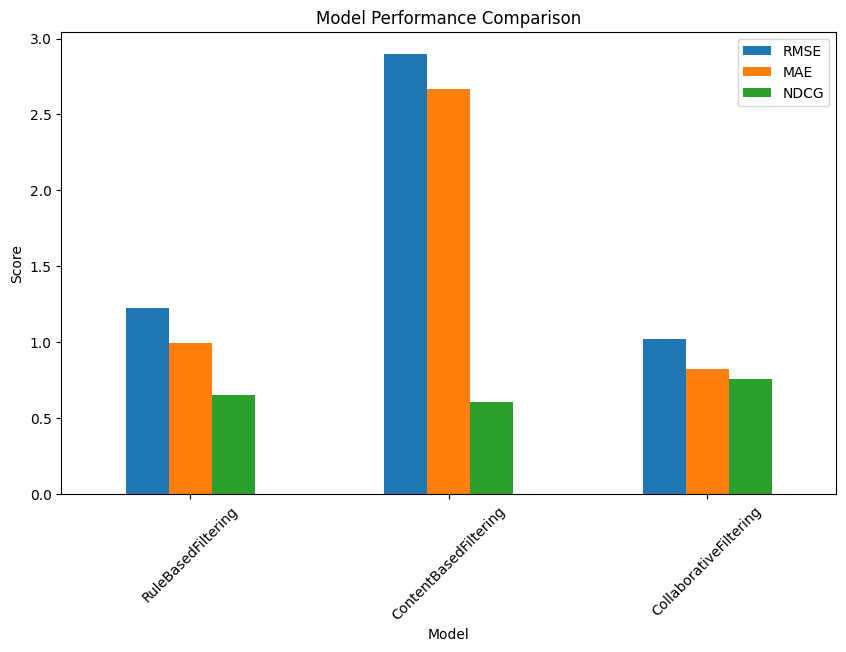

In [3]:
train_df, test_df = pipeline.partition_data(ratings_df, partition_type='temporal', save_path='../storage', data_name='temporal')
metadata_file='../storage/u.item'
ratings_file='../storage/train/temporal'

svd_params = {'n_factors': 200, 'n_epochs': 100, 'lr_all': 0.01, 'reg_all': 0.1}
collaborative_recommender = CollaborativeFiltering(
        ratings_file=ratings_file,
        metadata_file=metadata_file,
        algorithm=SVD(**svd_params)
    )
collaborative_recommender.fit()

models = {
    'RuleBasedFiltering': RuleBasedFiltering(ratings_file=ratings_file, metadata_file=metadata_file),
    'ContentBasedFiltering': ContentBasedFiltering(ratings_file=ratings_file, metadata_file=metadata_file),
    'CollaborativeFiltering': collaborative_recommender
}

results = defaultdict(list)

for name, model in models.items():
    rmse, mae, ndcg = evaluate_recommender(model, test_df)
    results['Model'].append(name)
    results['RMSE'].append(rmse)
    results['MAE'].append(mae)
    results['NDCG'].append(ndcg)

print('Performance for of the Temporal Partitioned Data:')
plot_results(results)

Performance for of the User-stratified Partitioned Data:


<Figure size 1000x500 with 0 Axes>

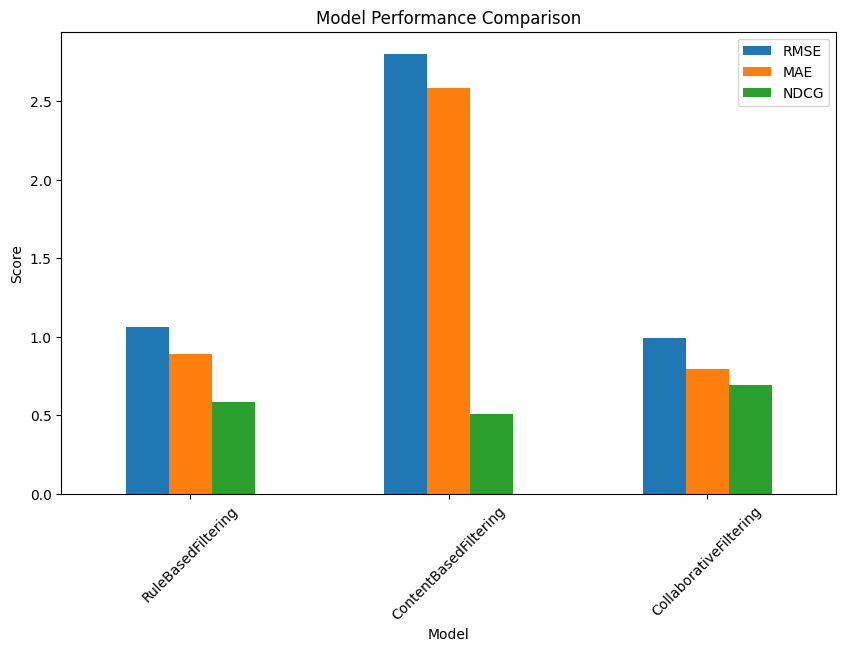

In [4]:
train_df, test_df = pipeline.partition_data(ratings_df, partition_type='stratified', save_path='../storage', data_name='stratified')
metadata_file='../storage/u.item'
ratings_file='../storage/train/stratified'

svd_params = {'n_factors': 200, 'n_epochs': 100, 'lr_all': 0.01, 'reg_all': 0.1}
collaborative_recommender = CollaborativeFiltering(
        ratings_file=ratings_file,
        metadata_file=metadata_file,
        algorithm=SVD(**svd_params)
    )
collaborative_recommender.fit()

models = {
    'RuleBasedFiltering': RuleBasedFiltering(ratings_file=ratings_file, metadata_file=metadata_file),
    'ContentBasedFiltering': ContentBasedFiltering(ratings_file=ratings_file, metadata_file=metadata_file),
    'CollaborativeFiltering': collaborative_recommender,
}

results = defaultdict(list)

for name, model in models.items():
    rmse, mae, ndcg = evaluate_recommender(model, test_df)
    results['Model'].append(name)
    results['RMSE'].append(rmse)
    results['MAE'].append(mae)
    results['NDCG'].append(ndcg)

print('Performance for of the User-stratified Partitioned Data:')
plot_results(results)

From the graph, we can see that collaborative filtering consistently achieves better scores across RMSE, MAE, and nDCG metrics in both temporal stratification and user stratification. This shows its ability to provide more accurate and relevant recommendations compared to rule-based and content-based filtering. This might be because collaborative filtering doesn't rely solely on predefined rules or item features but instead finds patterns in user rating behavior, uncovering hidden relationships between users and items. On the other hand, the content-based filter performs the worst, possibly because it relies only on item features and struggles to account for user-specific preferences effectively.